### Import python libraries, including scikit learn classifiers

In [1]:
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import RobustScaler
from sklearn.svm import LinearSVC, SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier, XGBRFClassifier
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Perceptron
from sklearn.preprocessing import RobustScaler, StandardScaler, Normalizer
import sys
import os
import sys
# sys.path.append('../')
import utils
from ei import EnsembleIntegration
from ens_selection import CES
import numpy as np
import pandas as pd
from utils import fmeasure_score

### Loading the dataset

In [2]:
# Load dataset
data_dir = 'diabetes/POND_data/'
data_dict = pd.read_csv(data_dir+'data_dictionary.csv')

nhanes_data = pd.read_csv(data_dir+'Pond_bivariate.csv')

exclude_vars = ['bmipct', 'INDFMPIR', 'SDDSRVYR']

nhanes_index = nhanes_data['SEQN'].values

preDM2_status = pd.read_csv(data_dir+ 'Pond_9918_cohortAll.csv')
preDM2_status = preDM2_status[['SEQN', 'preDM2']]
preDM2_status = preDM2_status[preDM2_status['SEQN'].isin(nhanes_index)]


preDM2_y = nhanes_data.merge(preDM2_status, 
                                left_on='SEQN', 
                                right_on='SEQN', 
                                how='left')['preDM2'].values.astype(int)

preDM2_with_status = nhanes_data.merge(preDM2_status, 
                                left_on='SEQN', 
                                right_on='SEQN', 
                                how='left')

preDM2_with_status.to_csv(data_dir+'Pond_all_var_labeled.csv', index=False)


nhanes_data.drop(columns=['preDM2', 'SEQN'] + exclude_vars, inplace=True, errors='ignore')

# Loading the ADA/AAP guideline
predm_ada = pd.read_csv(os.path.join(data_dir, 'Pond_aap.csv'))

predm_ada['ada'] = (predm_ada['bmipct'] >= 85) & ((predm_ada['HbpAAP']) | (predm_ada['ChlAAP']) |\
                    (predm_ada['raceAAP']))

predm_ada['ada'] = predm_ada['ada'].astype(float)

predm_ada_SEQN = predm_ada['SEQN'].values

intersect_set = set(predm_ada_SEQN).intersection(set(nhanes_index))
predm_ada_intersects = predm_ada.loc[predm_ada['SEQN'].isin(intersect_set)]
predm_ada_intersects = predm_ada_intersects.merge(preDM2_status, left_on='SEQN', right_on='SEQN', how='left')


modalities_mapping = {}
modalities = data_dict['Domain'].dropna().unique().tolist()

columns_na_mapping = {}



### Data imputation & one-hot encoding catgorical features

In [3]:
# Data Imputation
for c in nhanes_data.columns:
    col_type = data_dict.loc[data_dict['VariableNameNHANES']==c, 'Type'].values
    if c == "AgeAsthma":
        missed_idx = nhanes_data[c] == 100
    elif (col_type == 'Categorical') or (col_type == 'Binary'):
        val = nhanes_data[c].mode().values[0]
    elif (col_type == 'Continuous') or (col_type == 'Ordinal'):
        val = nhanes_data[c].median()
    nhanes_data.loc[:, [c]] = nhanes_data[c].fillna(val)
    columns_na_mapping[c] = val

# One-hot-encoding
ohe_dfs = []
cat_original = []
data_dict = data_dict[~data_dict['VariableNameNHANES'].isin(exclude_vars)]
for m in modalities:
    columns_names = data_dict.loc[data_dict['Domain']==m, 'VariableNameNHANES'].unique().tolist()
    df_ = nhanes_data[columns_names]
    cat_col = []
    dfs_ = []
    for c in columns_names:
        if (data_dict.loc[data_dict['VariableNameNHANES']==c, 'Type'].values[0] == 'Categorical') and len(nhanes_data[c].unique()) > 2:
            cat_ohe_df = pd.get_dummies(nhanes_data[c].astype(int), prefix=c)
            dfs_.append(cat_ohe_df)
        else:
            dfs_.append(nhanes_data[[c]])
    modalities_mapping[m] = pd.concat(dfs_, axis=1)

In [4]:
modalities_mapping['Diet'].to_csv('diet.csv')

In [5]:
modalities_mapping['Sociodemographic'].to_csv('sociodemographic.csv')

In [6]:
modalities_mapping['Health status'].to_csv('health_status.csv')

In [7]:
modalities_mapping['Other lifestyle behaviors'].to_csv('other_lifestyle_behavior.csv')

In [8]:
np.savetxt('labels.csv', preDM2_y.astype('uint8'), fmt="%i")

In [9]:
preDM2_y.astype('int')

array([0, 0, 0, ..., 0, 0, 0])

In [10]:
predm_ada_intersects.shape

(14292, 7)

In [11]:
predm_ada_intersects

,SEQN,bmipct,raceAAP,HbpAAP,ChlAAP,ada,preDM2
0,6,61.154585,1,0,0,0.0,0.0
1,8,4.591976,0,0,0,0.0,0.0
2,11,73.839703,0,0,0,0.0,0.0
3,21,99.647342,1,1,0,1.0,0.0
4,22,56.489236,1,0,0,0.0,0.0
...,...,...,...,...,...,...,...
14287,102877,88.608293,1,0,1,1.0,0.0
14288,102909,5.338729,0,0,1,0.0,0.0
14289,102915,91.141786,1,0,1,1.0,1.0
14290,102945,76.313626,1,0,0,0.0,0.0


In [12]:
from sklearn import metrics
def metrics_ADA(labels, predictions):
    perf_dict = {'metrics': [], 'scores': [], 'class': [], }

    frp_measures_pos = fmeasure_score(labels, predictions, pos_label=1)
    frp_measures_neg = fmeasure_score(labels, predictions,
                                      thres=1-frp_measures_pos['thres'], 
                                      pos_label=0)

    perf_dict['metrics'].append('F-measure (pos)')
    perf_dict['scores'].append(frp_measures_pos['F'])
    perf_dict['class'].append('pos')

    perf_dict['metrics'].append('PPV')
    perf_dict['scores'].append(frp_measures_pos['P'])
    perf_dict['class'].append('pos')

    perf_dict['metrics'].append('Sensitivity')
    perf_dict['scores'].append(frp_measures_pos['R'])
    perf_dict['class'].append('pos')

    perf_dict['metrics'].append('F-measure (neg)')
    perf_dict['scores'].append(frp_measures_neg['F'])
    perf_dict['class'].append('neg')

    perf_dict['metrics'].append('NPV')
    perf_dict['scores'].append(frp_measures_neg['P'])
    perf_dict['class'].append('neg')

    perf_dict['metrics'].append('Specificity')
    perf_dict['scores'].append(frp_measures_neg['R'])
    perf_dict['class'].append('neg')

    perf_dict['metrics'].append('BalancedACC')
    perf_dict['scores'].append((frp_measures_neg['R']+frp_measures_pos['R'])/2)
    perf_dict['class'].append('NA')

    perf_dict['metrics'].append('AUC')
    perf_dict['scores'].append(metrics.roc_auc_score(labels, predictions))
    perf_dict['class'].append('NA')

    df_temp = pd.DataFrame(perf_dict)
    return df_temp

In [13]:

def metrics_BA(labels, predictions):
    perf_dict = {'metrics': [], 'scores': [], 'class': []}
    one_minus_specs, sensitivity, thresholds = metrics.roc_curve(labels, predictions)
    specificity = 1 - one_minus_specs
    balance_accs = (specificity+sensitivity)/2

    np_balance_accs = np.array(balance_accs)
    max_thres = thresholds[np.argmax(np_balance_accs)]
    frp_measures_pos = fmeasure_score(labels, predictions, pos_label=1,
                                      thres=max_thres)
    frp_measures_neg = fmeasure_score(labels, predictions,
                                      thres=1-max_thres, 
                                      pos_label=0)

    perf_dict['metrics'].append('F-measure (pos)')
    perf_dict['scores'].append(frp_measures_pos['F'])
    perf_dict['class'].append('pos')

    perf_dict['metrics'].append('PPV')
    perf_dict['scores'].append(frp_measures_pos['P'])
    perf_dict['class'].append('pos')

    perf_dict['metrics'].append('Sensitivity')
    perf_dict['scores'].append(frp_measures_pos['R'])
    perf_dict['class'].append('pos')

    perf_dict['metrics'].append('F-measure (neg)')
    perf_dict['scores'].append(frp_measures_neg['F'])
    perf_dict['class'].append('neg')

    perf_dict['metrics'].append('NPV')
    perf_dict['scores'].append(frp_measures_neg['P'])
    perf_dict['class'].append('neg')

    perf_dict['metrics'].append('Specificity')
    perf_dict['scores'].append(frp_measures_neg['R'])
    perf_dict['class'].append('neg')

    perf_dict['metrics'].append('BalancedACC')
    perf_dict['scores'].append(max(balance_accs))
    perf_dict['class'].append('NA')

    perf_dict['metrics'].append('AUC')
    perf_dict['scores'].append(metrics.roc_auc_score(labels, predictions))
    perf_dict['class'].append('NA')
    df_temp = pd.DataFrame(perf_dict)
    df_temp['optimize'] = 'BalanceAcc'

    return df_temp

In [14]:
ada_scores = metrics_ADA(labels=predm_ada_intersects['preDM2'], 
                             predictions=predm_ada_intersects['ada'])
ada_scores

,metrics,scores,class
0,F-measure (pos),0.255451,pos
1,PPV,0.177011,pos
2,Sensitivity,0.458730,pos
3,F-measure (neg),0.768123,neg
4,NPV,0.891101,neg
5,Specificity,0.674972,neg
6,BalancedACC,0.566851,NA
7,AUC,0.566851,NA


In [15]:
base_predictors = {
    'NB': GaussianNB(),
    'LR': make_pipeline(StandardScaler(), LogisticRegression()),
    "SVM": make_pipeline(Normalizer(), SVC(kernel='poly', degree=1, probability=True)),
    "Perceptron": Perceptron(),
    'AdaBoost': AdaBoostClassifier(n_estimators=10),
    "DT": DecisionTreeClassifier(),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=10),
    "RF": RandomForestClassifier(n_estimators=100),
    "XGB": XGBClassifier(n_estimators=1), 
    'KNN': KNeighborsClassifier(n_neighbors=1),
}

meta_models = {
                "RF": RandomForestClassifier(),
                "SVM": SVC(kernel='linear', probability=True, max_iter=10000000),
                "NB": GaussianNB(),
                "LR": LogisticRegression(),
                "ADA": AdaBoostClassifier(),
                "DT": DecisionTreeClassifier(),
                "GB": GradientBoostingClassifier(),
                "KNN": KNeighborsClassifier(),
                "XGB": XGBClassifier()
}

sampling_schemes = 'undersampling'
random_seed = 42
# EI_models = []
EI_models = {}

import random
random.seed(41)
random_seeds = random.sample(range(100), 10)

for idx, random_seed in enumerate(random_seeds):
    print('running {}th EI'.format(idx))
    EI_undersampling = EnsembleIntegration(base_predictors=base_predictors,
                            k_outer=5,
                            k_inner=5,
                            n_samples=1,
                            sampling_strategy=sampling_schemes,
                            sampling_aggregation="None",
                            n_jobs=-1,  # set as -1 to use all available CPUs
                            random_state=random_seed,
                            project_name="nhanes_full_{}_{}".format(sampling_schemes, random_seed),
                            verbose=0)
    for m, data in modalities_mapping.items():
        EI_undersampling.train_base(data.values, preDM2_y, base_predictors, modality=m)
    EI_undersampling.train_meta(meta_models=meta_models) 
    EI_undersampling.save()
    EI_models[idx] = EI_undersampling


running 0th EI


###########################################################################################################
######################################## Sociodemographic modality ########################################
########################################################################################################### 


Training base predictors and generating data for analysis...
Generating meta training data via nested cross validation...
Training base predictors on outer training sets...

Base predictor training is complete: see "base_summary" attribute for a summary of base predictor performance. Meta training data can be found in "meta_training_data" and "meta_test_data" attributes. Run "train_meta" method for analysis of ensemble algorithms.


########################################################################################################
######################################## Health status modality ########################################
#########

/opt/anaconda3/envs/diabetes_ml/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Training base predictors on outer training sets...

Base predictor training is complete: see "base_summary" attribute for a summary of base predictor performance. Meta training data can be found in "meta_training_data" and "meta_test_data" attributes. Run "train_meta" method for analysis of ensemble algorithms.


#####################################################################################################
######################################## Analysing ensembles ########################################
##################################################################################################### 


Mean...
fmax (minority):  0.2780200051295204
f (majority):  0.7497777777777778
AUC:  0.6306999896627677
max MCC:  0.13212518649979105

CES...
fmax (minority):  0.2970073404856014
f (majority):  0.7854742827604032
AUC:  0.6577248092439849
max MCC:  0.15632762118954283

S.RF...
fmax (minority):  0.282249742002064
f (majority):  0.7532156480085159
AUC:  0.6364466767312688
max 

In [16]:
EI_undersampling.meta_summary['metrics']

,Mean,CES,S.RF,S.SVM,S.NB,S.LR,S.ADA,S.DT,S.GB,S.KNN,S.XGB
fmax (minority),0.281080,0.293253,0.280400,0.236486,0.303203,0.308331,0.299308,0.234279,0.302490,0.234279,0.273643
f (majority),0.746820,0.776595,0.746059,0.190165,0.746297,0.828279,0.829593,0.000000,0.765220,0.000000,0.710282
AUC,0.632704,0.648415,0.631683,0.519746,0.663810,0.672432,0.658688,0.539519,0.662213,0.524621,0.618451
max MCC,0.130731,0.150843,0.135288,0.024809,0.169386,0.174635,0.157687,0.066832,0.163690,0.027172,0.119685


In [17]:
EI_models_perf = {k: v for k, v in zip(sampling_schemes, EI_models)}

In [18]:
df_list = []
# for s in sampling_schemes:
#     if (s == 'hybrid'):
#         pred = EI_models[s].meta_predictions
import random
random.seed(41)
random_seeds = random.sample(range(100), 10)

for idx, random_seed in enumerate(random_seeds):
# for idx, pred_ in EI_models.items():
    pred_ = EnsembleIntegration().load('EI.nhanes_full_undersampling_{}'.format(random_seed))
    pred = pred_.meta_predictions
    for c in pred.columns:
        # if (c == 'S.LR'):
        if not (c == 'labels'):
            df = metrics_BA(pred['labels'], pred[c])
            df['ensemble method'] = c
            if idx is None:
                df['sampling method'] = 'original'
            else:
                df['sampling method'] = idx
            df['dummy'] = idx
            df_list.append(df)

cat_df = pd.concat(df_list)           

In [19]:
cat_df[(cat_df['optimize']=='BalanceAcc') & (cat_df['ensemble method']=='S.LR')]

,metrics,scores,class,optimize,ensemble method,sampling method,dummy
0,F-measure (pos),0.308721,pos,BalanceAcc,S.LR,0,0
1,PPV,0.209617,pos,BalanceAcc,S.LR,0,0
2,Sensitivity,0.585572,pos,BalanceAcc,S.LR,0,0
3,F-measure (neg),0.767555,neg,BalanceAcc,S.LR,0,0
4,NPV,0.912724,neg,BalanceAcc,S.LR,0,0
...,...,...,...,...,...,...,...
3,F-measure (neg),0.718643,neg,BalanceAcc,S.LR,9,9
4,NPV,0.919028,neg,BalanceAcc,S.LR,9,9
5,Specificity,0.589999,neg,BalanceAcc,S.LR,9,9
6,BalancedACC,0.625099,NA,BalanceAcc,S.LR,9,9


In [20]:
predm_ada_intersects.shape

(14292, 7)

### Build models with individual modalities using EI

In [21]:
base_predictors = {
    'NB': GaussianNB(),
    'LR': make_pipeline(StandardScaler(), LogisticRegression()),
    "SVM": make_pipeline(Normalizer(), SVC(kernel='poly', degree=1, probability=True)),
    "Perceptron": Perceptron(),
    'AdaBoost': AdaBoostClassifier(n_estimators=10),
    "DT": DecisionTreeClassifier(),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=10),
    "RF": RandomForestClassifier(n_estimators=100),
    "XGB": XGBClassifier(n_estimators=1), 
    'KNN': KNeighborsClassifier(n_neighbors=1),
}

meta_models = {
                "RF": RandomForestClassifier(),
                "SVM": SVC(kernel='linear', probability=True, max_iter=10000000),
                "NB": GaussianNB(),
                "LR": LogisticRegression(),
                "ADA": AdaBoostClassifier(),
                "DT": DecisionTreeClassifier(),
                "GB": GradientBoostingClassifier(),
                "KNN": KNeighborsClassifier(),
                "XGB": XGBClassifier()
}

random_seed = 42

EI_models_individual = {}

# best_ens = {'EI': 'S.LR',
#             'SES': {'LR': LogisticRegression()},
#             'Health status': {'LR': LogisticRegression()},
#             'diet':{"RF": XGBRFClassifier(n_estimators=100, booster='gbtree')},
#             'lifestyle': {'LR': LogisticRegression()}}

import random
random.seed(41)
random_seeds = random.sample(range(100), 10)


for m, data in modalities_mapping.items():
    in_list = []
    s = "undersampling"
    for idx, random_seed in enumerate(random_seeds):
        s = 'undersampling'
        EI_models_individual_s = {}
        EI_undersampling = EnsembleIntegration(base_predictors=base_predictors,
                            k_outer=5,
                            k_inner=5,
                            n_samples=1,
                            sampling_strategy='undersampling',
                            sampling_aggregation="None",
                            n_jobs=-1,  # set as -1 to use all available CPUs
                            random_state=random_seed,
                            project_name="{}_{}_{}".format(m, s, random_seed),
                            verbose=0)

        EI_undersampling.train_base(data.values, preDM2_y, base_predictors, modality=m)
        EI_undersampling.train_meta(meta_models=meta_models) 
        EI_undersampling.save()




###########################################################################################################
######################################## Sociodemographic modality ########################################
########################################################################################################### 


Training base predictors and generating data for analysis...
Generating meta training data via nested cross validation...
Training base predictors on outer training sets...

Base predictor training is complete: see "base_summary" attribute for a summary of base predictor performance. Meta training data can be found in "meta_training_data" and "meta_test_data" attributes. Run "train_meta" method for analysis of ensemble algorithms.


#####################################################################################################
######################################## Analysing ensembles ########################################
##############################

### Train with XGBoost

In [22]:
sampling_schemes = [
                    'undersampling', 
                    ]
concat_data = pd.concat([v for k, v in modalities_mapping.items()], axis=1)
XGB_ms = []

import random
random.seed(41)
random_seeds = random.sample(range(100), 10)


for idx, random_seed in enumerate(random_seeds):
    s='undersampling'
    EI_undersampling = EnsembleIntegration(base_predictors={"XGB": XGBClassifier()},
                            k_outer=5,
                            k_inner=5,
                            n_samples=1,
                            sampling_strategy=s,
                            sampling_aggregation="None",
                            n_jobs=-1,  # set as -1 to use all available CPUs
                            random_state=random_seed,
                            project_name="nhanes_full80_{}".format(s),
                            verbose=0)
    EI_undersampling.train_base(concat_data.values, preDM2_y, {"XGB": XGBClassifier()}, modality='concat')
    XGB_ms.append(pd.concat([EI_undersampling.meta_test_data[i] for i in range(5)]))



#################################################################################################
######################################## concat modality ########################################
################################################################################################# 


Training base predictors and generating data for analysis...
Generating meta training data via nested cross validation...
Training base predictors on outer training sets...

Base predictor training is complete: see "base_summary" attribute for a summary of base predictor performance. Meta training data can be found in "meta_training_data" and "meta_test_data" attributes. Run "train_meta" method for analysis of ensemble algorithms.


#################################################################################################
######################################## concat modality ########################################
####################################################################

In [23]:
dfm_list = []

import random
random.seed(41)
random_seeds = random.sample(range(100), 10)

for m, data in modalities_mapping.items():
    
    # pred_list = EI_models_individual[m]
    for idx, random_seed in enumerate(random_seeds):
        pred_ = EnsembleIntegration().load('EI.{}_undersampling_{}'.format(m,random_seed))
        pred = pred_.meta_predictions
        for c in pred.columns:
            # if c == best_ens[m]:
            if not (c == 'labels'):
                df = metrics_BA(pred['labels'], pred[c])
                df['ensemble method'] = c
                df['dataset'] = m
                df['sampling method'] = s
                df['dummy'] = idx
                dfm_list.append(df)


catm_df = pd.concat(dfm_list)     

In [24]:
xgb_perf = []
for idx, xgb_pred in enumerate(XGB_ms):
    # cat_base_pred_xgb = pd.concat([XGB_ms['hybrid'].meta_test_data[i] for i in range(5)])
    cat_pred = xgb_pred.values[:,0]
    cat_labels = xgb_pred.values[:,1]
    df_ = metrics_BA(cat_labels, cat_pred)
    df_['dummy'] = idx
    xgb_perf.append(df_)
    
xgb_perf_cat = pd.concat(xgb_perf)

In [25]:
xgb_perf_cat

,metrics,scores,class,optimize,dummy
0,F-measure (pos),0.283180,pos,BalanceAcc,0
1,PPV,0.179166,pos,BalanceAcc,0
2,Sensitivity,0.675124,pos,BalanceAcc,0
3,F-measure (neg),0.668373,neg,BalanceAcc,0
4,NPV,0.913916,neg,BalanceAcc,0
...,...,...,...,...,...
3,F-measure (neg),0.726021,neg,BalanceAcc,9
4,NPV,0.905873,neg,BalanceAcc,9
5,Specificity,0.605754,neg,BalanceAcc,9
6,BalancedACC,0.597156,NA,BalanceAcc,9


In [26]:
cat_df

,metrics,scores,class,optimize,ensemble method,sampling method,dummy
0,F-measure (pos),0.284887,pos,BalanceAcc,Mean,0,0
1,PPV,0.181557,pos,BalanceAcc,Mean,0,0
2,Sensitivity,0.661194,pos,BalanceAcc,Mean,0,0
3,F-measure (neg),0.681833,neg,BalanceAcc,Mean,0,0
4,NPV,0.913132,neg,BalanceAcc,Mean,0,0
...,...,...,...,...,...,...,...
3,F-measure (neg),0.710282,neg,BalanceAcc,S.XGB,9,9
4,NPV,0.902817,neg,BalanceAcc,S.XGB,9,9
5,Specificity,0.585433,neg,BalanceAcc,S.XGB,9,9
6,BalancedACC,0.586746,NA,BalanceAcc,S.XGB,9,9


In [27]:
def best_models(df, optimize="BalanceAcc"):
    metrics = ["AUC", "BalancedACC"]
    df_oi = df.loc[:, ['ensemble method', 'metrics', 'scores']]
    for m in metrics: 
        print(df_oi[df_oi['metrics']==m].groupby(['ensemble method', 'metrics']).mean().sort_values(by=['scores'], ascending=False))
    

In [28]:
best_models(cat_df)

                           scores
ensemble method metrics          
S.LR            AUC      0.670992
S.NB            AUC      0.663344
S.GB            AUC      0.662295
S.ADA           AUC      0.657642
CES             AUC      0.648456
S.RF            AUC      0.638099
Mean            AUC      0.629634
S.XGB           AUC      0.617019
S.KNN           AUC      0.536483
S.DT            AUC      0.526795
S.SVM           AUC      0.510813
                               scores
ensemble method metrics              
S.LR            BalancedACC  0.624717
S.NB            BalancedACC  0.619186
S.GB            BalancedACC  0.618870
S.ADA           BalancedACC  0.616510
CES             BalancedACC  0.611004
S.RF            BalancedACC  0.598036
Mean            BalancedACC  0.593695
S.XGB           BalancedACC  0.585968
S.KNN           BalancedACC  0.529378
S.DT            BalancedACC  0.526795
S.SVM           BalancedACC  0.515042


In [29]:
best_models(catm_df[catm_df['dataset']=="Sociodemographic"])

                           scores
ensemble method metrics          
S.LR            AUC      0.633825
S.NB            AUC      0.628757
S.GB            AUC      0.621966
S.ADA           AUC      0.621194
CES             AUC      0.613488
Mean            AUC      0.609184
S.RF            AUC      0.591986
S.XGB           AUC      0.578329
S.KNN           AUC      0.543876
S.DT            AUC      0.514222
S.SVM           AUC      0.491932
                               scores
ensemble method metrics              
S.LR            BalancedACC  0.601715
S.NB            BalancedACC  0.598388
S.GB            BalancedACC  0.595530
S.ADA           BalancedACC  0.593323
CES             BalancedACC  0.587243
Mean            BalancedACC  0.583413
S.RF            BalancedACC  0.567642
S.XGB           BalancedACC  0.560304
S.KNN           BalancedACC  0.535949
S.DT            BalancedACC  0.514293
S.SVM           BalancedACC  0.508579


In [30]:
best_models(catm_df[catm_df['dataset']=="Health status"])

                           scores
ensemble method metrics          
S.LR            AUC      0.605237
S.NB            AUC      0.601611
S.ADA           AUC      0.597900
S.GB            AUC      0.596707
CES             AUC      0.587850
Mean            AUC      0.583160
S.RF            AUC      0.566353
S.XGB           AUC      0.557002
S.KNN           AUC      0.530918
S.DT            AUC      0.514150
S.SVM           AUC      0.498539
                               scores
ensemble method metrics              
S.LR            BalancedACC  0.578836
S.NB            BalancedACC  0.574928
S.ADA           BalancedACC  0.574143
S.GB            BalancedACC  0.571777
CES             BalancedACC  0.568793
Mean            BalancedACC  0.562809
S.RF            BalancedACC  0.549705
S.XGB           BalancedACC  0.543511
S.KNN           BalancedACC  0.523890
S.DT            BalancedACC  0.514280
S.SVM           BalancedACC  0.508908


In [31]:
best_models(catm_df[catm_df['dataset']=="Diet"])

                           scores
ensemble method metrics          
S.LR            AUC      0.590767
S.NB            AUC      0.580000
S.ADA           AUC      0.578957
S.GB            AUC      0.576521
CES             AUC      0.553020
S.RF            AUC      0.550221
Mean            AUC      0.548760
S.XGB           AUC      0.540424
S.KNN           AUC      0.517324
S.DT            AUC      0.506661
S.SVM           AUC      0.500330
                               scores
ensemble method metrics              
S.LR            BalancedACC  0.572022
S.ADA           BalancedACC  0.566266
S.GB            BalancedACC  0.564292
S.NB            BalancedACC  0.562883
CES             BalancedACC  0.545003
Mean            BalancedACC  0.539336
S.RF            BalancedACC  0.539063
S.XGB           BalancedACC  0.533731
S.KNN           BalancedACC  0.515812
S.SVM           BalancedACC  0.508886
S.DT            BalancedACC  0.507263


In [32]:
best_models(catm_df[catm_df['dataset']=="Other lifestyle behaviors"])

                           scores
ensemble method metrics          
S.NB            AUC      0.544170
S.LR            AUC      0.542292
S.ADA           AUC      0.534173
S.GB            AUC      0.530676
Mean            AUC      0.525798
CES             AUC      0.519891
S.XGB           AUC      0.515188
S.RF            AUC      0.514746
S.KNN           AUC      0.507628
S.DT            AUC      0.502802
S.SVM           AUC      0.499369
                               scores
ensemble method metrics              
S.NB            BalancedACC  0.537915
S.LR            BalancedACC  0.536429
S.ADA           BalancedACC  0.530470
S.GB            BalancedACC  0.527639
Mean            BalancedACC  0.523152
CES             BalancedACC  0.521203
S.XGB           BalancedACC  0.517383
S.RF            BalancedACC  0.516046
S.SVM           BalancedACC  0.507880
S.KNN           BalancedACC  0.507688
S.DT            BalancedACC  0.504770


In [33]:
xgb_perf_cat['ensemble method'] = "concat"
best_models(xgb_perf_cat)

                           scores
ensemble method metrics          
concat          AUC      0.636119
                               scores
ensemble method metrics              
concat          BalancedACC  0.600974


### Make horizontal barplot of performance

ada score AUC [0.56685097]
ada score Balanced Accuracy [0.56685097]


/var/folders/m8/36vwj4hx0bg486z6m9wccfy40000gn/T/ipykernel_76799/2502750120.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  axs[r] = sns.barplot(ax=axs[r],
/var/folders/m8/36vwj4hx0bg486z6m9wccfy40000gn/T/ipykernel_76799/2502750120.py:83: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[r].legend().set_visible(False)
/var/folders/m8/36vwj4hx0bg486z6m9wccfy40000gn/T/ipykernel_76799/2502750120.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  axs[r] = sns.barplot(ax=axs[r],
/var/folders/m8/36vwj4hx0bg486z6m9wccfy40000gn/T/ipykernel_76799/2502750120.py:83: UserWarning: No artists wit

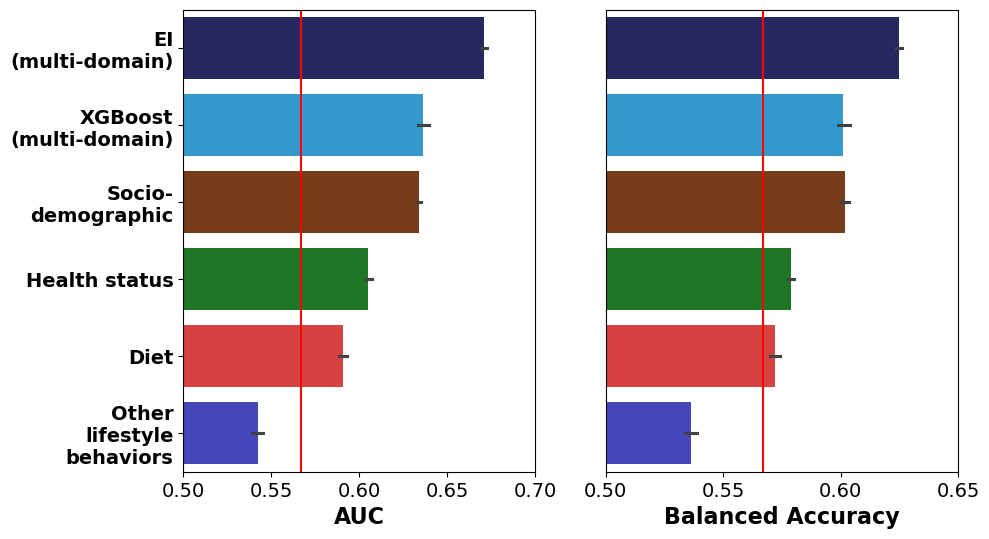

In [37]:

cat_df['dataset'] = 'EI'
xgb_perf_cat['dataset'] = 'XGBoost'
xgb_perf_cat['ensemble method'] = 'concat'

comb_df = pd.concat([
                    cat_df,
                    catm_df,
                    xgb_perf_cat
                    ])

best_model_dict = {'EI': 'S.LR',
                   'Sociodemographic': 'S.LR',
                   'Health status': 'S.LR',
                   'Diet':'S.LR',
                   'Other lifestyle behaviors': 'S.LR',
                   'XGBoost': 'concat'}


new_df = []
for k, v in best_model_dict.items():
    new_df.append(comb_df.loc[(comb_df['dataset']==k) & (comb_df['ensemble method']==v)])

comb_df = pd.concat(new_df)


comb_df = comb_df.loc[(comb_df['optimize']=='BalanceAcc')]

import matplotlib.pyplot as plt
import seaborn as sns

comb_df.replace({'Other lifestyle behaviors':'Other\nlifestyle\nbehaviors', 
                 'Diet': 'Diet',
                 'Health status': 'Health status',
                 'EI': 'EI\n(multi-domain)',
                 'BalancedACC':'Balanced Accuracy',
                 'XGBoost': 'XGBoost\n(multi-domain)',
                 'Sociodemographic': 'Socio-\ndemographic'
                 }, 
                 inplace=True)


comb_df.replace({'BalancedACC': 'Balanced Accuracy'}, inplace=True)
fig, axs = plt.subplots(1,2, figsize=(10, 6))
metrics_grid = [['AUC', 'Balanced Accuracy']]
ada_scores_ = ada_scores.replace({'BalancedACC':'Balanced Accuracy'})
xlim_left_grid = [[0.5, 0.5]]
xlim_right_grid = [[0.7, 0.65]]

color_map = ['#1D1F68', '#1AA2E7','#863a08', '#108618', '#ef2929', '#3332cd']
sns_cm = sns.color_palette(color_map)

for r in range(2):
    for c in range(1):
        metric = metrics_grid[c][r]
        perf_df_metric = comb_df.loc[(comb_df['metrics']==metric), :]
        ada_score = ada_scores_.loc[ada_scores_['metrics']==metric,'scores'].values
        print('ada score', metric, ada_score)
        axs[r] = sns.barplot(ax=axs[r], 
                                x='scores', 
                                data=perf_df_metric,
                                order=['EI\n(multi-domain)', 'XGBoost\n(multi-domain)','Socio-\ndemographic', 'Health status', 
                                        'Diet', 'Other\nlifestyle\nbehaviors'], 
                                y='dataset',
                                palette=sns_cm
                                )
        axs[r].axvline(x=ada_score, c='red')
        axs[r].set_xticks(np.arange(0.5, xlim_right_grid[c][r]+0.05, 0.05))
        axs[r].tick_params(axis='x', labelsize=14)
        axs[r].tick_params(axis='y', labelsize=14, labelrotation=0)
        for label in axs[r].get_yticklabels():
            label.set_fontweight('bold')
            label.set_horizontalalignment('right')
        axs[r].set_xlabel(metric, fontsize=16, fontweight='bold')
        # if metric == 'NPV':
        axs[r].set_xlim(left=xlim_left_grid[c][r], 
                        right=xlim_right_grid[c][r]
                        # right=xlim_right_grid[c][r]
                        )
        if r > 0:
            axs[r].get_yaxis().set_visible(False)
        else:
            axs[r].set_ylabel('')
        axs[r].legend().set_visible(False)
# fig.legend(loc="upper right")
fig.savefig('diabetes/results/nhanes_80_auc_ba.png', bbox_inches="tight", dpi=400)

In [38]:
comb_df.loc[comb_df['dataset']=='EI\n(multi-domain)']

,metrics,scores,class,optimize,ensemble method,sampling method,dummy,dataset
0,F-measure (pos),0.308721,pos,BalanceAcc,S.LR,0,0,EI\n(multi-domain)
1,PPV,0.209617,pos,BalanceAcc,S.LR,0,0,EI\n(multi-domain)
2,Sensitivity,0.585572,pos,BalanceAcc,S.LR,0,0,EI\n(multi-domain)
3,F-measure (neg),0.767555,neg,BalanceAcc,S.LR,0,0,EI\n(multi-domain)
4,NPV,0.912724,neg,BalanceAcc,S.LR,0,0,EI\n(multi-domain)
...,...,...,...,...,...,...,...,...
3,F-measure (neg),0.718643,neg,BalanceAcc,S.LR,9,9,EI\n(multi-domain)
4,NPV,0.919028,neg,BalanceAcc,S.LR,9,9,EI\n(multi-domain)
5,Specificity,0.589999,neg,BalanceAcc,S.LR,9,9,EI\n(multi-domain)
6,Balanced Accuracy,0.625099,NA,BalanceAcc,S.LR,9,9,EI\n(multi-domain)


In [39]:
comb_df[comb_df['metrics']=='AUC'].pivot(index='dummy',
                                        columns='dataset',
                                        values='scores').to_csv('diabetes/results/nhanes_all_AUC.csv')

In [40]:
comb_df[comb_df['metrics']=='Balanced Accuracy'].pivot(index='dummy',
                                        columns='dataset',
                                        values='scores').to_csv('diabetes/results/nhanes_all_BA.csv')

In [41]:
ada_scores

,metrics,scores,class
0,F-measure (pos),0.255451,pos
1,PPV,0.177011,pos
2,Sensitivity,0.458730,pos
3,F-measure (neg),0.768123,neg
4,NPV,0.891101,neg
5,Specificity,0.674972,neg
6,BalancedACC,0.566851,NA
7,AUC,0.566851,NA


### Statistical test of performances

In [42]:
import os, fnmatch
import pandas as pd
import numpy as np
from statsmodels.stats.multitest import fdrcorrection
from scipy.stats import ranksums

def pairwise_rank_sum(df):
    a_groups = df.columns.to_list()
    b_groups = df.columns.to_list()
    num_groups = len(a_groups)
    pairwise_mat = -1*np.ones((num_groups, num_groups))
    idx_list = []
    pval_list = []
    print(df)
    for idx_a, a in enumerate(a_groups):
        for idx_b, b in enumerate(b_groups):
            if idx_a != idx_b:
                idx_list.append([idx_a, idx_b])
                # print(df[a].values, df[b].values)
                pval_list.append(ranksums(df[a].values, df[b].values, alternative='greater')[1])
                # pairwise_mat[idx_a, idx_b] = ranksums(df[a].values, df[b].values).pvalue
                # pairwise_mat[idx_b, idx_a] = ranksums(df[a].values, df[b].values).pvalue
    print('p_val:', pval_list)
    pval_list = fdrcorrection(pval_list)[1]
    print('fdr_corrected:',pval_list)
    for idx, pval in zip(idx_list, pval_list):
        pairwise_mat[idx[0], idx[1]] = pval
        # pairwise_mat[idx[1], idx[0]] = pval
    return pd.DataFrame(pairwise_mat, index=a_groups, columns=b_groups)


In [44]:
AUC_df = pd.read_csv('./diabetes/results/nhanes_all_AUC.csv').drop(columns=['dummy'])

In [45]:
BA_df = pd.read_csv('./diabetes/results/nhanes_all_BA.csv').drop(columns=['dummy'])

In [46]:
pairwise_rank_sum(BA_df)

       Diet  EI\n(multi-domain)  Health status  Other\nlifestyle\nbehaviors  \
0  0.568245            0.624148       0.576567                     0.536926   
1  0.569084            0.622916       0.580416                     0.540484   
2  0.576041            0.627402       0.582310                     0.541023   
3  0.575144            0.629215       0.579699                     0.541175   
4  0.574186            0.625860       0.577604                     0.536063   
5  0.570804            0.623593       0.580669                     0.533793   
6  0.573083            0.624175       0.574487                     0.532738   
7  0.572985            0.621420       0.581366                     0.526317   
8  0.575764            0.623344       0.577738                     0.538696   
9  0.564889            0.625099       0.577499                     0.537081   

   Socio-\ndemographic  XGBoost\n(multi-domain)  
0             0.603231                 0.601225  
1             0.600954        

,Diet,EI\n(multi-domain),Health status,Other\nlifestyle\nbehaviors,Socio-\ndemographic,XGBoost\n(multi-domain)
Diet,-1.000000,0.999921,0.999921,0.000181,0.999921,0.999921
EI\n(multi-domain),0.000181,-1.000000,0.000181,0.000181,0.000181,0.000181
Health status,0.000408,0.999921,-1.000000,0.000181,0.999921,0.999921
Other\nlifestyle\nbehaviors,0.999921,0.999921,0.999921,-1.000000,0.999921,0.999921
Socio-\ndemographic,0.000181,0.999921,0.000181,0.000181,-1.000000,0.449692
XGBoost\n(multi-domain),0.000181,0.999921,0.000181,0.000181,0.999921,-1.000000


In [47]:
pairwise_rank_sum(AUC_df)

       Diet  EI\n(multi-domain)  Health status  Other\nlifestyle\nbehaviors  \
0  0.587941            0.669614       0.604093                     0.545827   
1  0.586752            0.670858       0.612150                     0.548426   
2  0.595700            0.674709       0.605260                     0.542648   
3  0.595130            0.674733       0.603811                     0.551102   
4  0.592681            0.671333       0.602920                     0.538601   
5  0.589485            0.672464       0.605478                     0.540679   
6  0.595229            0.667439       0.602977                     0.536584   
7  0.586757            0.664335       0.605776                     0.532909   
8  0.592516            0.672004       0.605737                     0.543622   
9  0.585476            0.672432       0.604172                     0.542522   

   Socio-\ndemographic  XGBoost\n(multi-domain)  
0             0.634526                 0.638177  
1             0.633172        

,Diet,EI\n(multi-domain),Health status,Other\nlifestyle\nbehaviors,Socio-\ndemographic,XGBoost\n(multi-domain)
Diet,-1.000000,0.999921,0.999921,0.000168,0.999921,0.999921
EI\n(multi-domain),0.000168,-1.000000,0.000168,0.000168,0.000168,0.000168
Health status,0.000168,0.999921,-1.000000,0.000168,0.999921,0.999921
Other\nlifestyle\nbehaviors,0.999921,0.999921,0.999921,-1.000000,0.999921,0.999921
Socio-\ndemographic,0.000168,0.999921,0.000168,0.000168,-1.000000,0.999921
XGBoost\n(multi-domain),0.000168,0.999921,0.000168,0.000168,0.289918,-1.000000


In [48]:
def process(l, p, th):
    temp = p.copy()
    temp[temp >= th] = 1
    temp[temp < th] = 0
    return (metrics.balanced_accuracy_score(l, temp))

def ba_max(y_true, y_pred):
    one_minus_specs, sensitivity, thresholds = metrics.roc_curve(y_true, y_pred)
    specificity = 1 - one_minus_specs
    balance_accs = (specificity+sensitivity)/2
    return max(balance_accs)


from sklearn.metrics import roc_auc_score, precision_recall_curve, \
    matthews_corrcoef, precision_recall_fscore_support, make_scorer
ba_scorer = make_scorer(ba_max, greater_is_better=True)

In [49]:
base_predictors = {
    'NB': GaussianNB(),
    'LR': make_pipeline(StandardScaler(), LogisticRegression()),
    "SVM": make_pipeline(Normalizer(), SVC(kernel='poly', degree=1, probability=True)),
    "Perceptron": Perceptron(),
    'AdaBoost': AdaBoostClassifier(n_estimators=10),
    "DT": DecisionTreeClassifier(),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=10),
    "RF": RandomForestClassifier(n_estimators=100),
    "XGB": XGBClassifier(n_estimators=1), 
    'KNN': KNeighborsClassifier(n_neighbors=1),
}

meta_models = {
                "RF": RandomForestClassifier(),
                "SVM": SVC(kernel='linear', probability=True, max_iter=10000000),
                "NB": GaussianNB(),
                "LR": LogisticRegression(),
                "ADA": AdaBoostClassifier(),
                "DT": DecisionTreeClassifier(),
                "GB": GradientBoostingClassifier(),
                "KNN": KNeighborsClassifier(),
                "XGB": XGBClassifier()
}



# sampling_schemes = ['oversampling', 'undersampling', 'hybrid', None]
sampling_schemes = [  
                    'undersampling'
                    # None
                    ]
random_seed = 42
# # EI_models = []
# EI_models = {}

# import random
# random.seed(41)
# random_seeds = random.sample(range(100), 10)

# for idx, random_seed in enumerate(random_seeds):
#     print('running {}th EI'.format(idx))
#     for s in sampling_schemes:
EI_undersampling = EnsembleIntegration(base_predictors=base_predictors,
                        k_outer=5,
                        k_inner=5,
                        n_samples=1,
                        sampling_strategy='undersampling',
                        sampling_aggregation="None",
                        n_jobs=-1,  # set as -1 to use all available CPUs
                        random_state=random_seed,
                        project_name="nhanes_full80_{}".format('undersampling'),
                        model_building=True,
                        verbose=0)
for m, data in modalities_mapping.items():
    EI_undersampling.train_base(data.values, preDM2_y, base_predictors, modality=m)
EI_undersampling.train_meta(meta_models=meta_models) 
# EI_undersampling.save()
# EI_models[idx] = EI_undersampling




###########################################################################################################
######################################## Sociodemographic modality ########################################
########################################################################################################### 


Training base predictors and generating data for analysis...
Generating meta training data via nested cross validation...
Training base predictors on outer training sets...

Base predictor training is complete: see "base_summary" attribute for a summary of base predictor performance. Meta training data can be found in "meta_training_data" and "meta_test_data" attributes. Run "train_meta" method for analysis of ensemble algorithms.

Training base predictors and generating data for final ensemble...
Generating meta training data via nested cross validation...
Training base predictors on outer training sets...

Model building: meta training data for the final model 

In [51]:
!pip3 install shap

  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 562.8/562.8 kB 3.4 MB/s  0:00:00m ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 15.5 MB/s  0:00:000.4 MB/s eta 0:00:01
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 3.0 MB/s  0:00:12a 0:00:010:00:01:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 2.0 MB/s  0:00:01a 0:00:010:00:01:01
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [shap]━━━━━━━━━━━━━ 4/6 [numba]


In [56]:
!pip3 install "numpy>=1.25.2" pandas==1.5.3

  Using cached numpy-2.4.3-cp311-cp311-macosx_14_0_arm64.whl.metadata (6.6 kB)
Using cached numpy-2.4.3-cp311-cp311-macosx_14_0_arm64.whl (5.5 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.24.4
    Uninstalling numpy-1.24.4:
      Successfully uninstalled numpy-1.24.4


In [57]:
import joblib
joblib.parallel.DEFAULT_BACKEND = 'sequential'

In [64]:
import importlib
import interpretation
importlib.reload(interpretation)
from interpretation import *
from sklearn.metrics import balanced_accuracy_score

EI_undersampling.n_jobs = 1
EI_undersampling.parallel_backend = 'sequential'

# Wrap balanced_accuracy_score to always use predict, not predict_proba
from sklearn.metrics import make_scorer
ba_scorer = make_scorer(balanced_accuracy_score, response_method='predict')

EI_int = EI_interpreter(EI_object=EI_undersampling,
                        base_predictors=base_predictors,
                        meta_models=meta_models,
                        modalities=modalities_mapping,
                        y=preDM2_y,
                        n_repeats=10,
                        metric=balanced_accuracy_score,
                        random_state=42,
                        )
EI_int.rank_product_score()


 Working on Sociodemographic data... 

Training base predictors on outer training sets...

 Working on Health status data... 

Training base predictors on outer training sets...

 Working on Other lifestyle behaviors data... 

Training base predictors on outer training sets...

 Working on Diet data... 

Training base predictors on outer training sets...
      local_model_PI base predictor          modality ensemble_method    LMR  \
0           0.034154             NB  Sociodemographic            S.RF  0.325   
1           0.034154             NB  Sociodemographic            S.RF  0.325   
2           0.034154             NB  Sociodemographic            S.RF  0.325   
3           0.034154             NB  Sociodemographic            S.RF  0.325   
4           0.034154             NB  Sociodemographic            S.RF  0.325   
...              ...            ...               ...             ...    ...   
1075        0.000075            KNN              Diet            S.RF  0.975   
10

In [65]:
EI_int_df = EI_int.ensemble_feature_ranking['S.LR'].copy()

In [66]:
EI_int_df

,modality,feature,RPS,feature rank,ensemble method
0,Sociodemographic,RIAGENDR,0.029324,1.0,S.LR
21,Sociodemographic,FdStmp,0.052230,2.0,S.LR
37,Health status,BMXWT,0.077206,3.0,S.LR
93,Diet,PTot,0.085833,4.0,S.LR
90,Diet,DMilk,0.099271,5.0,S.LR
...,...,...,...,...,...
12,Sociodemographic,RaceEth_0,0.409054,104.0,S.LR
25,Sociodemographic,HOQ065_0,0.430405,105.0,S.LR
27,Sociodemographic,HOQ065_2,0.433514,106.0,S.LR
58,Other lifestyle behaviors,HHSmk,0.482083,107.0,S.LR


In [67]:
EI_int.ensemble_feature_ranking['S.LR'].iloc[:30].to_csv('diabetes/results/int.csv')

### Baseline Reproduction Evidence

Model                                AUC   Bal.Acc
------------------------------------------------------------
  EI (multi-domain)               0.6710    0.6247
  XGBoost (multi-domain)          0.6361    0.6010
  Socio- demographic              0.6338    0.6017
  Health status                   0.6052    0.5788
  Diet                            0.5908    0.5720
  Other lifestyle behaviors       0.5423    0.5364
  AAP/ADA Guideline               0.5669    0.5669


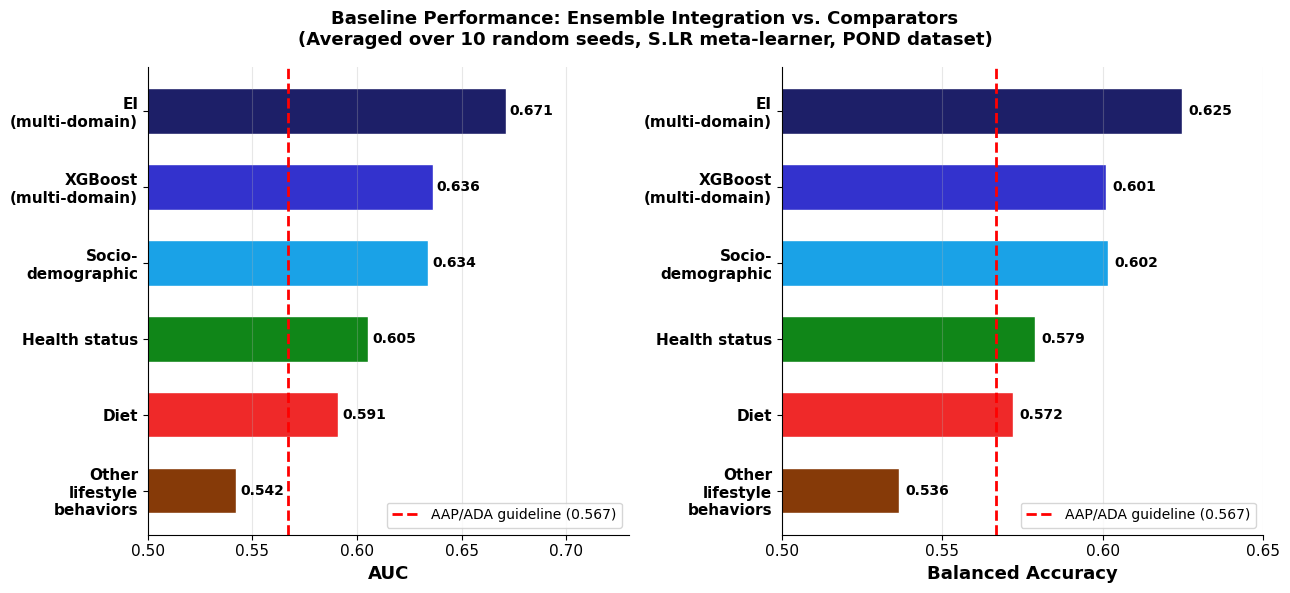

✓ Saved: diabetes/results/fig1_baseline_comparison.png


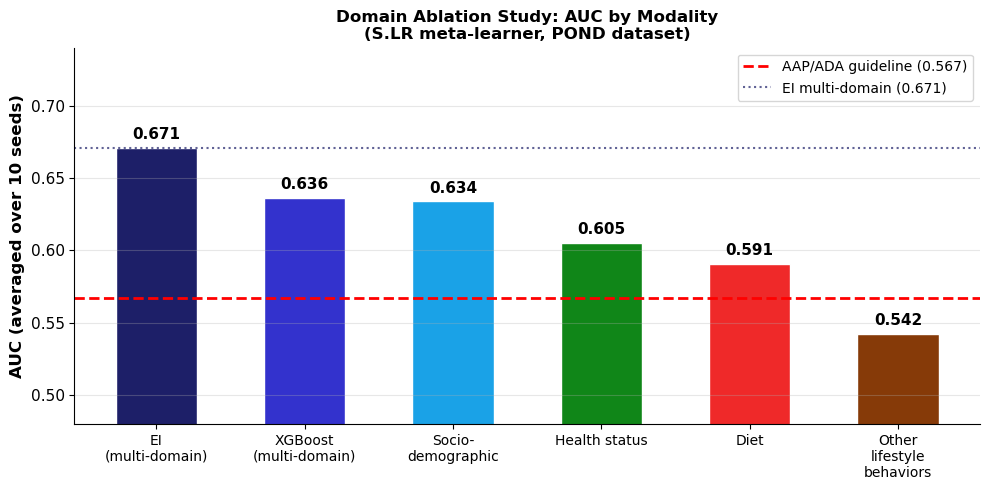

✓ Saved: diabetes/results/fig2_modality_ablation.png


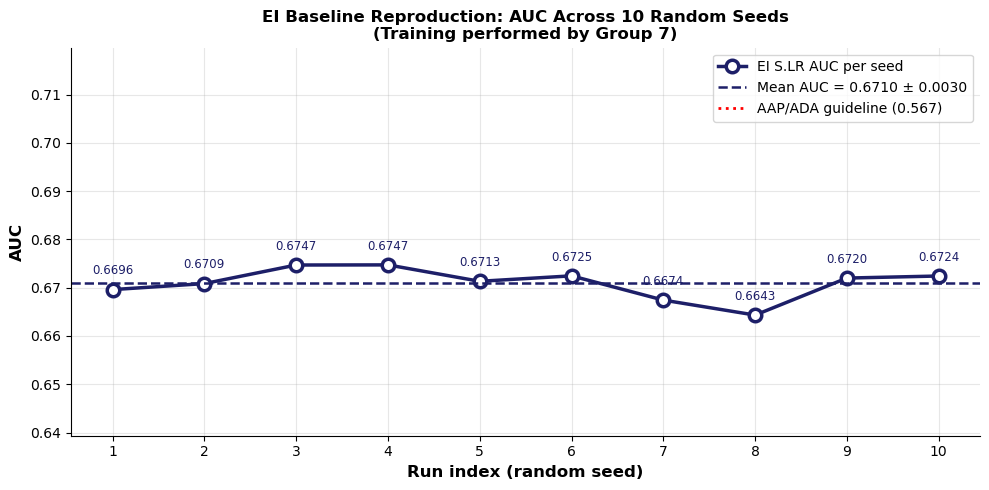

✓ Saved: diabetes/results/fig3_seed_stability.png

SUMMARY FOR REPORT
EI multi-domain AUC  mean ± std : 0.6710 ± 0.0030
EI multi-domain AUC  range      : 0.6643 - 0.6747
Published target (McDonough '24): 0.6700
Reproduction gap                : 0.0010
All 3 figures saved to diabetes/results/


In [69]:
"""
════════════════════════════════════════════════════════════════════
Saves: diabetes/results/fig1_baseline_comparison.png
       diabetes/results/fig2_modality_ablation.png
       diabetes/results/fig3_seed_stability.png
════════════════════════════════════════════════════════════════════
"""

import matplotlib.pyplot as plt
import numpy as np
import os

os.makedirs('diabetes/results', exist_ok=True)

# ─────────────────────────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────────────────────────
BEST_MODEL = 'S.LR'
OPTIMIZE   = 'BalanceAcc'
COLORS     = ['#1D1F68', '#3332cd', '#1AA2E7', '#108618', '#ef2929', '#863a08']

# ─────────────────────────────────────────────────────────────────
# PREPARE DATA COPIES  (don't mutate originals)
# ─────────────────────────────────────────────────────────────────
_cat  = cat_df.copy()
_catm = catm_df.copy()
_xgb  = xgb_perf_cat.copy()

# Make sure dataset column exists on EI multi-domain df
if 'dataset' not in _cat.columns:
    _cat['dataset'] = 'EI'
if 'ensemble method' not in _xgb.columns:
    _xgb['ensemble method'] = 'concat'
if 'optimize' not in _xgb.columns:
    _xgb['optimize'] = OPTIMIZE

# Normalise metric name  BalancedACC → Balanced Accuracy
for df in [_cat, _catm, _xgb]:
    df['metrics'] = df['metrics'].replace({'BalancedACC': 'Balanced Accuracy'})

# ─────────────────────────────────────────────────────────────────
# HELPER: extract mean score
# ─────────────────────────────────────────────────────────────────
def mean_score(df, dataset_col, dataset_val, metric, model=BEST_MODEL, opt=OPTIMIZE):
    mask = (
        (df[dataset_col] == dataset_val) &
        (df['metrics']   == metric) &
        (df['optimize']  == opt) &
        (df['ensemble method'] == model)
    )
    v = df.loc[mask, 'scores']
    return v.mean() if len(v) > 0 else np.nan

def mean_xgb(metric):
    mask = (_xgb['metrics'] == metric) & (_xgb['optimize'] == OPTIMIZE)
    v = _xgb.loc[mask, 'scores']
    return v.mean() if len(v) > 0 else np.nan

def ada_val(metric):
    # ada_scores uses 'BalancedACC' spelling
    m2 = 'BalancedACC' if metric == 'Balanced Accuracy' else metric
    v = ada_scores.loc[ada_scores['metrics'] == m2, 'scores']
    if len(v) == 0:
        v = ada_scores.loc[ada_scores['metrics'] == metric, 'scores']
    return v.values[0] if len(v) > 0 else np.nan

# ─────────────────────────────────────────────────────────────────
# COLLECT NUMBERS FOR ALL 6 MODELS
# ─────────────────────────────────────────────────────────────────
datasets = [
    ('EI\n(multi-domain)',          'EI',                        _cat,  'dataset'),
    ('XGBoost\n(multi-domain)',     '__xgb__',                   _xgb,  'dataset'),
    ('Socio-\ndemographic',         'Sociodemographic',          _catm, 'dataset'),
    ('Health status',               'Health status',             _catm, 'dataset'),
    ('Diet',                        'Diet',                      _catm, 'dataset'),
    ('Other\nlifestyle\nbehaviors', 'Other lifestyle behaviors', _catm, 'dataset'),
]

labels, auc_vals, ba_vals = [], [], []
for label, key, df, col in datasets:
    labels.append(label)
    if key == '__xgb__':
        auc_vals.append(mean_xgb('AUC'))
        ba_vals.append(mean_xgb('Balanced Accuracy'))
    else:
        auc_vals.append(mean_score(df, col, key, 'AUC'))
        ba_vals.append(mean_score(df, col, key, 'Balanced Accuracy'))

ada_auc = ada_val('AUC')
ada_ba  = ada_val('Balanced Accuracy')

# Print for verification
print("=" * 60)
print(f"{'Model':<32} {'AUC':>7}  {'Bal.Acc':>8}")
print("-" * 60)
for l, a, b in zip(labels, auc_vals, ba_vals):
    print(f"  {l.replace(chr(10),' '):<30} {a:>7.4f}  {b:>8.4f}")
print(f"  {'AAP/ADA Guideline':<30} {ada_auc:>7.4f}  {ada_ba:>8.4f}")
print("=" * 60)


# ═════════════════════════════════════════════════════════════════
# FIGURE 1 — Horizontal bar: AUC + Balanced Accuracy side by side
# ═════════════════════════════════════════════════════════════════
fig1, axes = plt.subplots(1, 2, figsize=(13, 6))
fig1.suptitle(
    'Baseline Performance: Ensemble Integration vs. Comparators\n'
    '(Averaged over 10 random seeds, S.LR meta-learner, POND dataset)',
    fontsize=13, fontweight='bold'
)

for ax, vals, metric_name, a_val, xlim in [
    (axes[0], auc_vals, 'AUC',               ada_auc, (0.50, 0.73)),
    (axes[1], ba_vals,  'Balanced Accuracy',  ada_ba,  (0.50, 0.65)),
]:
    bars = ax.barh(labels[::-1], vals[::-1], color=COLORS[::-1],
                   height=0.6, edgecolor='white')
    ax.axvline(x=a_val, color='red', linewidth=2, linestyle='--',
               label=f'AAP/ADA guideline ({a_val:.3f})')
    ax.set_xlabel(metric_name, fontsize=13, fontweight='bold')
    ax.set_xlim(*xlim)
    ax.set_xticks(np.arange(xlim[0], xlim[1] + 0.005, 0.05))
    ax.tick_params(axis='x', labelsize=11)
    ax.tick_params(axis='y', labelsize=11)
    for lbl in ax.get_yticklabels():
        lbl.set_fontweight('bold')
    for bar, val in zip(bars, vals[::-1]):
        if not np.isnan(val):
            ax.text(bar.get_width() + 0.002,
                    bar.get_y() + bar.get_height() / 2,
                    f'{val:.3f}', va='center', ha='left',
                    fontsize=10, fontweight='bold')
    ax.legend(fontsize=10, loc='lower right')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
fig1.savefig('diabetes/results/fig1_baseline_comparison.png',
             dpi=180, bbox_inches='tight')
plt.show()
print("✓ Saved: diabetes/results/fig1_baseline_comparison.png")


# ═════════════════════════════════════════════════════════════════
# FIGURE 2 — Vertical bar: domain ablation (AUC)
# ═════════════════════════════════════════════════════════════════
fig2, ax2 = plt.subplots(figsize=(10, 5))
bars2 = ax2.bar(labels, auc_vals, color=COLORS, edgecolor='white', width=0.55)

ax2.axhline(y=ada_auc, color='red', linewidth=2, linestyle='--',
            label=f'AAP/ADA guideline ({ada_auc:.3f})')
ax2.axhline(y=auc_vals[0], color='#1D1F68', linewidth=1.5, linestyle=':',
            alpha=0.7, label=f'EI multi-domain ({auc_vals[0]:.3f})')

ax2.set_ylabel('AUC (averaged over 10 seeds)', fontsize=12, fontweight='bold')
ax2.set_title('Domain Ablation Study: AUC by Modality\n'
              '(S.LR meta-learner, POND dataset)',
              fontsize=12, fontweight='bold')
ax2.set_ylim(0.48, 0.74)
ax2.tick_params(axis='x', labelsize=10)
ax2.tick_params(axis='y', labelsize=11)

for bar, val in zip(bars2, auc_vals):
    if not np.isnan(val):
        ax2.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.004,
                 f'{val:.3f}', ha='center', va='bottom',
                 fontsize=11, fontweight='bold')

ax2.legend(fontsize=10)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(axis='y', alpha=0.3)
plt.tight_layout()
fig2.savefig('diabetes/results/fig2_modality_ablation.png',
             dpi=180, bbox_inches='tight')
plt.show()
print("✓ Saved: diabetes/results/fig2_modality_ablation.png")


# ═════════════════════════════════════════════════════════════════
# FIGURE 3 — Seed-by-seed AUC (baseline reproduction evidence)
# ═════════════════════════════════════════════════════════════════
ei_per_seed = _cat[
    (_cat['metrics']          == 'AUC') &
    (_cat['optimize']         == OPTIMIZE) &
    (_cat['ensemble method']  == BEST_MODEL)
].sort_values('dummy')

seeds    = ei_per_seed['dummy'].values + 1   # 1-indexed for readability
seed_auc = ei_per_seed['scores'].values
mean_auc = seed_auc.mean()
std_auc  = seed_auc.std()

fig3, ax3 = plt.subplots(figsize=(10, 5))
ax3.plot(seeds, seed_auc, 'o-', color='#1D1F68', linewidth=2.5,
         markersize=9, markerfacecolor='white', markeredgewidth=2.5,
         label='EI S.LR AUC per seed')
ax3.axhline(y=mean_auc, color='#1D1F68', linewidth=1.8, linestyle='--',
            label=f'Mean AUC = {mean_auc:.4f} ± {std_auc:.4f}')
ax3.axhline(y=ada_auc, color='red', linewidth=2, linestyle=':',
            label=f'AAP/ADA guideline ({ada_auc:.3f})')

for s, a in zip(seeds, seed_auc):
    ax3.annotate(f'{a:.4f}', (s, a),
                 textcoords='offset points', xytext=(0, 11),
                 ha='center', fontsize=8.5, color='#1D1F68')

ax3.set_xlabel('Run index (random seed)', fontsize=12, fontweight='bold')
ax3.set_ylabel('AUC', fontsize=12, fontweight='bold')
ax3.set_title('EI Baseline Reproduction: AUC Across 10 Random Seeds\n'
              '(Training performed by Group 7)',
              fontsize=12, fontweight='bold')
ax3.set_xticks(seeds)
y_lo = max(0.50, seed_auc.min() - 0.025)
y_hi = min(0.75, seed_auc.max() + 0.045)
ax3.set_ylim(y_lo, y_hi)
ax3.legend(fontsize=10)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.grid(alpha=0.3)
plt.tight_layout()
fig3.savefig('diabetes/results/fig3_seed_stability.png',
             dpi=180, bbox_inches='tight')
plt.show()
print("✓ Saved: diabetes/results/fig3_seed_stability.png")

# ─────────────────────────────────────────────────────────────────
# SUMMARY PRINT
# ─────────────────────────────────────────────────────────────────
print()
print("=" * 55)
print("SUMMARY FOR REPORT")
print("=" * 55)
print(f"EI multi-domain AUC  mean ± std : {mean_auc:.4f} ± {std_auc:.4f}")
print(f"EI multi-domain AUC  range      : {seed_auc.min():.4f} - {seed_auc.max():.4f}")
print(f"Published target (McDonough '24): 0.6700")
print(f"Reproduction gap                : {abs(mean_auc - 0.67):.4f}")
print(f"All 3 figures saved to diabetes/results/")